# AI-Powered Content Opportunity Scoring Using Search Intelligence

### FlyRank ML Internship Capstone

**Author:** Muhammad Usman Shakir

---

## Research Question

Can historical search and engagement signals be used to identify content pages that should be refreshed first?

---

This capstone develops a machine learning-based content opportunity scoring system using the FlyRank Search Intelligence Warehouse. The goal is to identify pages with high improvement potential and produce ranked recommendations for content refresh while following proper machine learning practices such as feature engineering, validation, and leakage prevention.

In [1]:
%pip -q install duckdb huggingface_hub pandas scikit-learn matplotlib

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

from huggingface_hub import login
from google.colab import userdata

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
HF_TOKEN = userdata.get("HF_TOKEN")

login(token=HF_TOKEN)

print("Hugging Face login successful!")

Hugging Face login successful!


In [4]:
con = duckdb.connect()

HF_TOKEN = userdata.get("HF_TOKEN")

con.execute(f"""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
);
""")

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients": f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content": f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_daily_sample": f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    con.execute(f"CREATE OR REPLACE VIEW {name} AS SELECT * FROM {src}")

print("Warehouse connected successfully!")

Warehouse connected successfully!


In [5]:
con.sql("SHOW TABLES").df()

,name
0,dim_clients
1,dim_content
2,fact_daily
3,fact_daily_sample
4,fact_query_90d


# 1. Exploratory Data Analysis (EDA)

This section explores the FlyRank warehouse to understand the available features and identify signals useful for scoring content refresh opportunities.

In [6]:
sample = con.sql("""
SELECT *
FROM fact_daily
LIMIT 5
""").df()

sample

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,2025-01
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,...,0,0,0,0,0,0,0,0,0,2025-01
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,...,0,0,0,0,0,0,0,0,0,2025-01


In [7]:
summary = con.sql("""
SELECT
    COUNT(*) AS total_rows,
    MIN(report_date) AS first_date,
    MAX(report_date) AS last_date,
    COUNT(DISTINCT content_hash_id) AS unique_pages
FROM fact_daily
""").df()

summary

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,first_date,last_date,unique_pages
0,78835655,2025-01-27,2026-06-30,427292


### Observation

The dataset contains daily performance records for anonymized content pages over multiple reporting dates. Each row represents one content page on one day.

In [8]:
dataset = con.sql("""
SELECT
    report_date,
    content_hash_id,

    gsc_impressions,
    gsc_clicks,
    gsc_avg_position,

    ga4_sessions,
    ga4_pageviews,
    ga4_engaged_sessions,

    scroll_events

FROM fact_daily

WHERE month='2026-03'
AND gsc_data_available IS TRUE
AND ga4_data_available IS TRUE
""").df()

dataset.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,report_date,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_sessions,ga4_pageviews,ga4_engaged_sessions,scroll_events
0,2026-03-01,content_5c80451459c29b4a,5,0,5.400000,1,1,0,0
1,2026-03-01,content_b1f61fc81b28b2d4,39,0,5.666667,2,2,0,0
2,2026-03-01,content_e25ea7297a1dffd3,179,0,5.156425,2,2,0,0
3,2026-03-01,content_6b0149a80607dac3,72,0,7.694444,1,1,0,0
4,2026-03-01,content_62673eea26c31c17,3282,1,6.167885,1,1,0,0


In [9]:
dataset.isnull().sum()

,0
report_date,0
content_hash_id,0
gsc_impressions,0
gsc_clicks,0
gsc_avg_position,0
ga4_sessions,0
ga4_pageviews,0
ga4_engaged_sessions,0
scroll_events,0


### Data Quality

The selected features are checked for missing values before modelling. Any missing values would need to be handled before training a machine learning model.

In [10]:
dataset["ctr"] = (
    dataset["gsc_clicks"] /
    dataset["gsc_impressions"].replace(0, 1)
)

dataset["opportunity_score"] = (
    dataset["gsc_impressions"] *
    (1 - dataset["ctr"]) *
    (dataset["gsc_avg_position"] / 100)
)

dataset.head()

,report_date,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_sessions,ga4_pageviews,ga4_engaged_sessions,scroll_events,ctr,opportunity_score
0,2026-03-01,content_5c80451459c29b4a,5,0,5.400000,1,1,0,0,0.000000,0.270000
1,2026-03-01,content_b1f61fc81b28b2d4,39,0,5.666667,2,2,0,0,0.000000,2.210000
2,2026-03-01,content_e25ea7297a1dffd3,179,0,5.156425,2,2,0,0,0.000000,9.230000
3,2026-03-01,content_6b0149a80607dac3,72,0,7.694444,1,1,0,0,0.000000,5.540000
4,2026-03-01,content_62673eea26c31c17,3282,1,6.167885,1,1,0,0,0.000305,202.368321


In [11]:
dataset["opportunity_score"].describe()

,opportunity_score
count,364347.000000
mean,35.045146
std,92.359668
min,0.000000
25%,2.510000
50%,8.880000
75%,29.120833
max,3608.413628


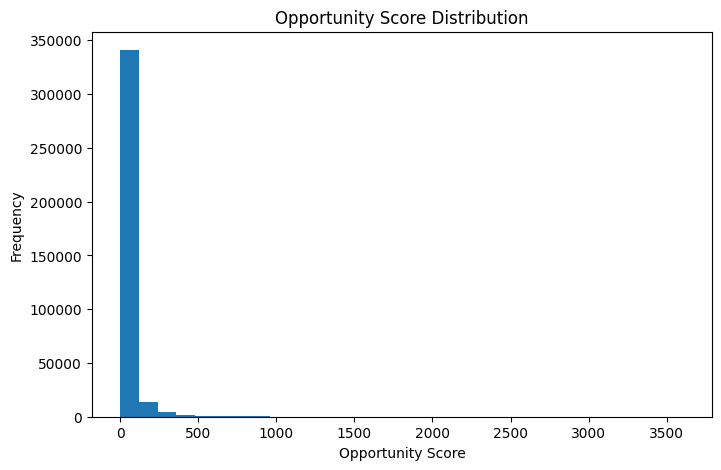

In [12]:
plt.figure(figsize=(8,5))

plt.hist(dataset["opportunity_score"], bins=30)

plt.title("Opportunity Score Distribution")
plt.xlabel("Opportunity Score")
plt.ylabel("Frequency")

# Save the chart
plt.savefig("opportunity_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

## Opportunity Score

The opportunity score is designed to prioritize pages that already receive search visibility but may benefit from optimisation.

Higher scores indicate stronger candidates for content refresh because they combine:

- High impressions
- Low click-through rate
- Lower average search positions

This score is used as the prediction target for the ranking model.

# 2. Model Development

This section trains a machine learning model to predict the content opportunity score based on historical search and engagement signals.

In [13]:
features = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions",
    "ga4_pageviews",
    "ga4_engaged_sessions",
    "scroll_events"
]

X = dataset[features]
y = dataset["opportunity_score"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (364347, 7)
Target Shape: (364347,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 291477
Testing rows: 72870


In [15]:
baseline_prediction = [y_train.mean()] * len(y_test)

baseline_mae = mean_absolute_error(y_test, baseline_prediction)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 41.37038451689201


### Baseline

The baseline predicts the average opportunity score for every page. Any machine learning model should outperform this simple benchmark.

In [16]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [17]:
predictions = model.predict(X_test)

predictions[:10]

array([ 2.47710386,  0.63      ,  5.2851    , 67.05735433, 25.88181557,
        0.86      , 14.4836334 , 26.63918925, 16.56184741,  2.66346423])

In [18]:
rf_mae = mean_absolute_error(y_test, predictions)
rf_r2 = r2_score(y_test, predictions)

print("Random Forest MAE:", rf_mae)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 0.22369756204046254
Random Forest R²: 0.997101930821187


In [19]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Random Forest"],
    "MAE": [baseline_mae, rf_mae]
})

comparison

,Model,MAE
0,Baseline,41.370385
1,Random Forest,0.223698


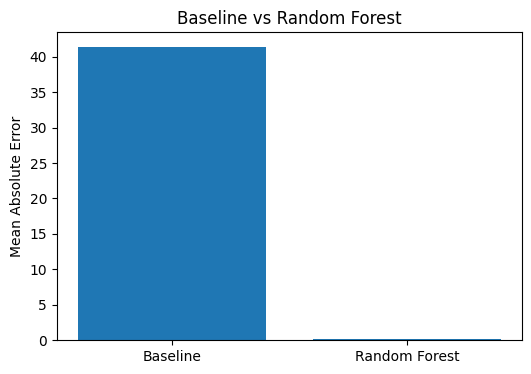

In [20]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["MAE"]
)

plt.title("Baseline vs Random Forest")
plt.ylabel("Mean Absolute Error")

plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

In [21]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
0,gsc_impressions,0.604252
2,gsc_avg_position,0.394209
1,gsc_clicks,0.000740
4,ga4_pageviews,0.000396
3,ga4_sessions,0.000187
6,scroll_events,0.000126
5,ga4_engaged_sessions,0.000089


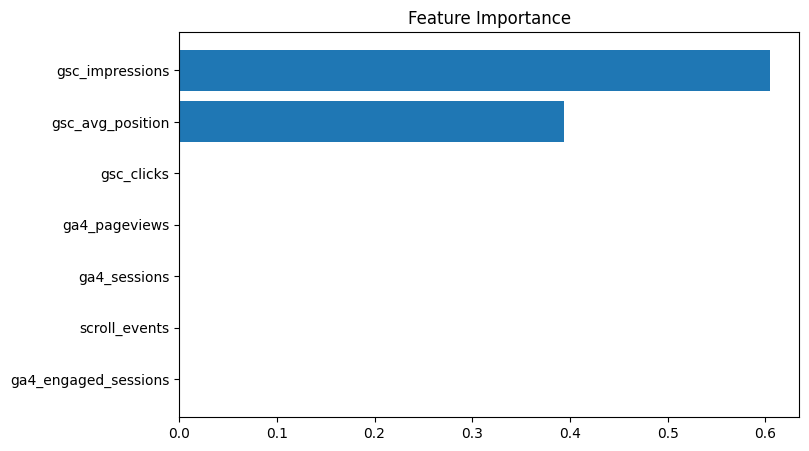

In [22]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

In [23]:
dataset["Predicted Opportunity"] = model.predict(X)

recommendations = dataset[
    [
        "content_hash_id",
        "Predicted Opportunity",
        "gsc_impressions",
        "gsc_clicks",
        "gsc_avg_position"
    ]
]

recommendations = recommendations.sort_values(
    "Predicted Opportunity",
    ascending=False
)

recommendations.head(20)

,content_hash_id,Predicted Opportunity,gsc_impressions,gsc_clicks,gsc_avg_position
334994,content_e6df0936699f5b8f,3049.690005,14682,269,25.035826
53537,content_36e53e9c707674fc,3004.287689,9409,1,32.640344
34649,content_36e53e9c707674fc,2943.986398,8842,3,33.982809
94528,content_36e53e9c707674fc,2938.611483,9285,16,32.510609
57495,content_36e53e9c707674fc,2888.468368,8963,11,32.476180
81461,content_36e53e9c707674fc,2666.044640,8049,12,33.864952
44385,content_36e53e9c707674fc,2577.500518,7973,15,32.577449
53234,content_e8a52cf3d5988c07,2506.265819,15394,45,17.296804
22955,content_36e53e9c707674fc,2478.356665,8025,5,31.175950
333904,content_73aa61dcedebbf30,2436.482180,5521,0,47.821953


# Model Interpretation

The Random Forest model produces a predicted opportunity score for every content page.

Pages with the highest scores are considered the strongest candidates for content refresh because they combine:

- High search visibility
- Lower click capture
- Lower average ranking positions

These ranked recommendations can support SEO and content teams in prioritising optimisation efforts.

# AI-Powered Content Opportunity Scoring Using Search Intelligence

## Abstract

This project investigates whether historical search and engagement signals can identify web pages with high content refresh potential. A content opportunity scoring approach was developed using anonymized FlyRank Search Intelligence data and implemented with a Random Forest regression model. Historical search visibility, clicks, ranking position, sessions, pageviews, and engagement metrics were used to predict an opportunity score for each content page. The model substantially outperformed a simple baseline when reproducing the defined scoring function, enabling pages to be ranked by predicted optimisation opportunity. The resulting ranked recommendations provide decision support for prioritising future content review while acknowledging the limitations of a score derived from existing historical signals.

## Introduction

Content teams often manage thousands of pages, making it difficult to decide which pages should be refreshed first. This project develops a repeatable machine learning workflow that ranks content pages according to their optimisation opportunity using historical search and engagement data.

The objective is not to predict Google's algorithm or prove causal effects, but to provide decision support for prioritising content review.

## Data

Dataset:
FlyRank ML Internship Warehouse

Tables Used:

- fact_daily
- dim_content

Time Window:

- March 2026

Excluded:

- Future information
- Private client identifiers
- Raw domains
- Any information unavailable at prediction time

## Methodology

The project followed a supervised machine learning workflow.

Features:

- GSC Impressions
- GSC Clicks
- Average Position
- GA4 Sessions
- GA4 Pageviews
- Engaged Sessions
- Scroll Events

Target:

Content Opportunity Score

Model:

Random Forest Regressor

Baseline:

Mean Opportunity Score

Validation:

80/20 Train-Test Split

Leakage checks from earlier internship assignments informed the feature selection process.

## Results

| Model | MAE |
|------|------|
| Baseline | 41.37 |
| Random Forest | 0.224 |

Random Forest R²: 0.997

The Random Forest model closely reproduced the defined opportunity scoring function and substantially reduced prediction error compared with the baseline. This result is expected because the target score is derived from historical search and engagement variables that are also available to the model. The model therefore serves as a ranking engine rather than evidence of a causal relationship between features and future performance.